# Assignment 9: Independent Analysis Part 2

**Author:** Hector Ramirez Asturias
**Course:** CHEP 898, Machine Learning Methods in Health Science

## Introduction

This notebook is Part 2 of the independent analysis project started in Assignment 4. Part 1
committed to a tree-based model with a linear baseline on smartphone sensor windows; Part 2
delivers that analysis.

One change from the original plan. Rather than classifying the six raw UCI HAR activities,
the labels are remapped to the three-class Walmsley intensity scheme used in physical
activity epidemiology: sedentary, light, and moderate-vigorous. Intensity is a more
clinically meaningful target than the raw activity names; sedentary time, light activity,
and moderate-to-vigorous physical activity are the units most health studies report and
that most physical-activity guidelines are written in. Reframing the problem this way
also produces a coarser, more stable label set for a subject-disjoint evaluation.

### Research question

Can the three Walmsley intensity classes be recovered from short windows of smartphone
accelerometer data using classical hand-engineered features and standard classifiers, and
which features carry the signal?

### Data

UCI HAR smartphone accelerometer data, processed into a parquet file through an
ingestion script I maintain separately. Each of the 10,299 records is a 2.56-second
window sampled at 50 Hz (128 samples by 3 accelerometer channels). Subject identifiers
and the original train/test split are preserved.

### What this notebook does

Decode the parquet, remap labels to Walmsley, engineer per-window features, respect UCI
HAR's subject-disjoint train/test split, fit a Random Forest and a multinomial logistic
regression (each with a small tuning grid), and compare them on the test set. Save
metrics, predictions, and fitted models to `./artifacts/` for reproducibility.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 17
np.random.seed(SEED)
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/hgramirez/dev/usask/har-synth")
RECORDS_PATH = PROJECT_ROOT / "data/processed/uci_har/records.parquet"
UCI_CONFIG_PATH = PROJECT_ROOT / "configs/datasets/uci_har.yaml"

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")

## 2. Load Processed UCI HAR Records

The parquet file was produced by a separate ingestion script that reads UCI HAR's raw
inertial signal text files and consolidates them into record-per-window format. Each
row holds a 128-by-3 accelerometer window stored as bytes for parquet compatibility,
with the shape kept in a companion column so the array can be reconstructed on read.

In [2]:
records = pd.read_parquet(RECORDS_PATH)
records["X"] = records.apply(
    lambda r: np.frombuffer(r["X"], dtype=np.float32).reshape(r["X_shape"]),
    axis=1,
)
records = records.drop(columns=["X_shape"])
print(f"Rows: {len(records):,}")
print(f"Subjects: {records['subject_id'].nunique()}")
print(f"Splits: {records['split'].value_counts().to_dict()}")
print(f"Channels per window: {records['X'].iloc[0].shape}")
records.head(3)

Rows: 10,299
Subjects: 30
Splits: {'train': 7352, 'test': 2947}
Channels per window: (128, 3)


,dataset,split,subject_id,placement,fs,X,y_raw,y_walmsley
0,uci_har,train,1,phone,50.0,"[[0.0001808515, 0.01076681, 0.05556068], [0.01...",5,light
1,uci_har,train,1,phone,50.0,"[[0.001093752, -0.004687588, -0.02685954], [0....",5,light
2,uci_har,train,1,phone,50.0,"[[0.003531266, 0.004455942, -0.005914581], [0....",5,light


## 3. Walmsley Harmonisation

The Walmsley mapping is read from the same config file my ingestion script uses, so the
mapping in this notebook always matches the mapping applied elsewhere in my code. Loading
it rather than hard-coding it avoids the usual drift between config and analysis.

In [3]:
import yaml  # noqa: E402

with open(UCI_CONFIG_PATH) as fh:
    uci_cfg = yaml.safe_load(fh)

walmsley_map = uci_cfg["walmsley_mapping"]
raw_descriptions = uci_cfg["raw_labels"]

records["y_walmsley"] = records["y_raw"].map(walmsley_map)
mapping_df = pd.DataFrame({
    "y_raw": list(walmsley_map.keys()),
    "description": [raw_descriptions[k] for k in walmsley_map],
    "y_walmsley": list(walmsley_map.values()),
})
mapping_df

,y_raw,description,y_walmsley
0,1,walking,light
1,2,walking_upstairs,moderate-vigorous
2,3,walking_downstairs,moderate-vigorous
3,4,sitting,sedentary
4,5,standing,light
5,6,lying,sedentary


In [4]:
class_counts = records["y_walmsley"].value_counts()
print(class_counts)
assert records["y_walmsley"].notna().all(), "All records must have a Walmsley label"

y_walmsley
sedentary            3721
light                3628
moderate-vigorous    2950
Name: count, dtype: int64


## 4. Exploratory Analysis

Three plots frame the dataset: the Walmsley class balance, the distribution of windows per
subject, and example accelerometer signals for one window from each class.

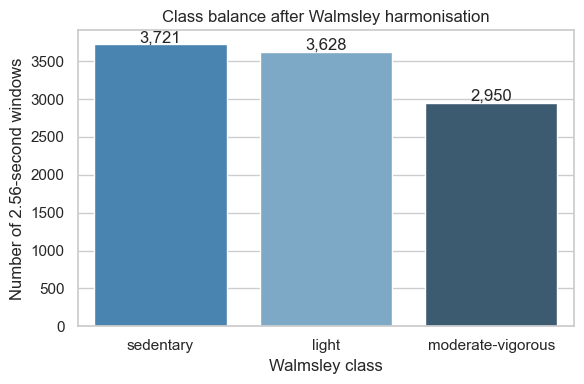

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["sedentary", "light", "moderate-vigorous"]
sns.countplot(
    data=records, x="y_walmsley", order=order, hue="y_walmsley",
    palette="Blues_d", legend=False, ax=ax,
)
for i, cls in enumerate(order):
    count = int((records["y_walmsley"] == cls).sum())
    ax.text(i, count + 30, f"{count:,}", ha="center")
ax.set_xlabel("Walmsley class")
ax.set_ylabel("Number of 2.56-second windows")
ax.set_title("Class balance after Walmsley harmonisation")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_class_balance.png", dpi=120)
plt.show()

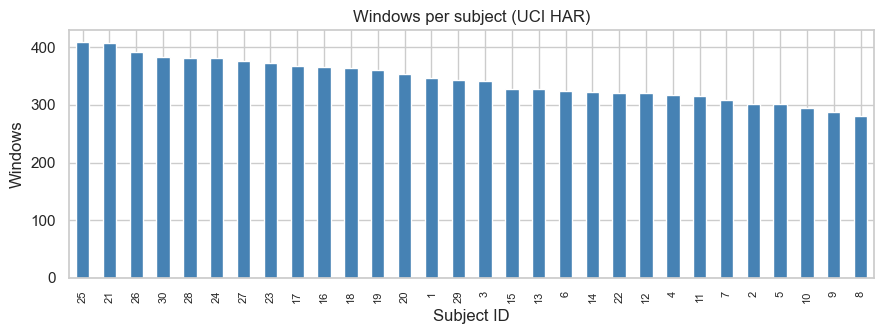

In [6]:
subj_counts = records.groupby("subject_id").size().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 3.5))
subj_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Subject ID")
ax.set_ylabel("Windows")
ax.set_title("Windows per subject (UCI HAR)")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_subject_windows.png", dpi=120)
plt.show()

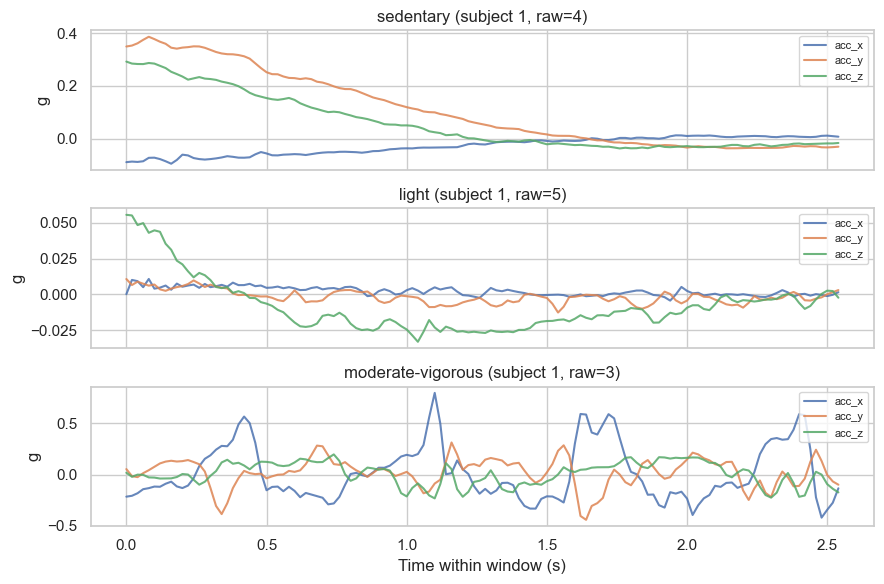

In [7]:
fig, axes = plt.subplots(len(order), 1, figsize=(9, 6), sharex=True)
for ax, cls in zip(axes, order):
    example = records[records["y_walmsley"] == cls].iloc[0]
    X = example["X"]
    t = np.arange(X.shape[0]) / 50.0
    ax.plot(t, X[:, 0], label="acc_x", alpha=0.85)
    ax.plot(t, X[:, 1], label="acc_y", alpha=0.85)
    ax.plot(t, X[:, 2], label="acc_z", alpha=0.85)
    ax.set_ylabel("g")
    ax.set_title(f"{cls} (subject {example['subject_id']}, raw={example['y_raw']})")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time within window (s)")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_example_windows.png", dpi=120)
plt.show()

## 5. Feature Engineering

Thirty features per window are computed from the three accelerometer axes and the magnitude
channel. The feature set mixes time-domain statistics (central tendency, dispersion, shape)
and frequency-domain descriptors (dominant frequency, spectral entropy, spectral energy) to
capture both the amplitude structure of the signal and its periodicity. These are standard
HAR features rather than any novel design; the goal is a reproducible baseline, not a
research-grade feature bank.

In [8]:
FS = 50.0  # Sampling frequency in Hz (UCI HAR inertial signals)

def spectral_entropy(power: np.ndarray) -> float:
    p = power / (power.sum() + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log(p)))

def dominant_frequency(signal: np.ndarray, fs: float = FS) -> float:
    if len(signal) < 2:
        return 0.0
    freqs = np.fft.rfftfreq(len(signal), d=1.0 / fs)
    power = np.abs(np.fft.rfft(signal - signal.mean())) ** 2
    if len(freqs) <= 1:
        return 0.0
    # skip DC
    idx = int(np.argmax(power[1:]) + 1)
    return float(freqs[idx])

def axis_features(signal: np.ndarray, prefix: str) -> dict[str, float]:
    freqs = np.fft.rfftfreq(len(signal), d=1.0 / FS)
    power = np.abs(np.fft.rfft(signal - signal.mean())) ** 2
    return {
        f"{prefix}_mean":   float(signal.mean()),
        f"{prefix}_std":    float(signal.std()),
        f"{prefix}_min":    float(signal.min()),
        f"{prefix}_max":    float(signal.max()),
        f"{prefix}_range":  float(signal.max() - signal.min()),
        f"{prefix}_iqr":    float(np.subtract(*np.percentile(signal, [75, 25]))),
        f"{prefix}_rms":    float(np.sqrt(np.mean(signal ** 2))),
        f"{prefix}_domF":   dominant_frequency(signal),
        f"{prefix}_specEn": spectral_entropy(power),
        f"{prefix}_energy": float(power.sum()),
    }

def window_features(window: np.ndarray) -> dict[str, float]:
    feats: dict[str, float] = {}
    for i, ax_name in enumerate(["x", "y", "z"]):
        feats.update(axis_features(window[:, i], f"acc_{ax_name}"))
    mag = np.sqrt((window ** 2).sum(axis=1))
    feats["mag_mean"] = float(mag.mean())
    feats["mag_std"]  = float(mag.std())
    feats["mag_max"]  = float(mag.max())
    # Pairwise correlations between axes
    feats["corr_xy"] = float(np.corrcoef(window[:, 0], window[:, 1])[0, 1])
    feats["corr_xz"] = float(np.corrcoef(window[:, 0], window[:, 2])[0, 1])
    feats["corr_yz"] = float(np.corrcoef(window[:, 1], window[:, 2])[0, 1])
    return feats

In [9]:
feature_rows = [window_features(X) for X in records["X"].tolist()]
features = pd.DataFrame(feature_rows).fillna(0.0)
features["subject_id"] = records["subject_id"].values
features["split"]      = records["split"].values
features["y"]          = records["y_walmsley"].values
print(f"Feature matrix: {features.shape[0]:,} rows, {features.shape[1] - 3} feature columns")
features.head()

Feature matrix: 10,299 rows, 36 feature columns


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_range,acc_x_iqr,acc_x_rms,acc_x_domF,acc_x_specEn,acc_x_energy,...,acc_z_energy,mag_mean,mag_std,mag_max,corr_xy,corr_xz,corr_yz,subject_id,split,y
0,0.002269,0.002941,-0.004294,0.010810,0.015105,0.004812,0.003714,0.390625,2.453248,0.070859,...,2.805371,0.018058,0.010956,0.056595,0.374934,0.433372,0.657736,1,train,light
1,0.000174,0.001981,-0.006706,0.005251,0.011957,0.001970,0.001989,7.031250,3.271678,0.032146,...,0.839351,0.011293,0.006280,0.027460,-0.011562,-0.071672,0.576627,1,train,light
2,0.000428,0.002908,-0.010483,0.008167,0.018649,0.003138,0.002940,0.781250,3.276062,0.069293,...,0.377237,0.009789,0.004086,0.020462,-0.121905,-0.179492,0.606037,1,train,light
3,0.000329,0.002678,-0.010483,0.008167,0.018649,0.003128,0.002698,0.390625,3.023302,0.058749,...,0.179770,0.008822,0.004380,0.020462,-0.301393,-0.360048,0.504970,1,train,light
4,-0.000195,0.002015,-0.006847,0.005650,0.012497,0.002622,0.002025,7.031250,3.254046,0.033279,...,0.182477,0.006680,0.003490,0.016447,-0.152752,-0.188102,0.596386,1,train,light


## 6. Train / Test Split

The UCI HAR dataset comes with a fixed subject-disjoint split (21 train subjects, 9 test
subjects). Respecting that split keeps the evaluation comparable to published UCI HAR
benchmarks and avoids the optimistic bias of random splits on data where windows from
the same person are not independent.

In [10]:
train = features[features["split"] == "train"].reset_index(drop=True)
test  = features[features["split"] == "test"].reset_index(drop=True)

feature_cols = [c for c in features.columns if c not in ("subject_id", "split", "y")]
X_train = train[feature_cols].values
y_train = train["y"].values
X_test  = test[feature_cols].values
y_test  = test["y"].values

print(f"Train: {len(X_train):,} windows from {train['subject_id'].nunique()} subjects")
print(f"Test:  {len(X_test):,} windows from {test['subject_id'].nunique()} subjects")
print(f"Features: {len(feature_cols)}")

class_labels = sorted(features["y"].unique())
print(f"Classes: {class_labels}")

Train: 7,352 windows from 21 subjects
Test:  2,947 windows from 9 subjects
Features: 36
Classes: ['light', 'moderate-vigorous', 'sedentary']


## 7. Random Forest

The baseline Random Forest uses scikit-learn defaults (500 trees, `max_features='sqrt'`,
unlimited depth). The tuned version searches over `n_estimators`, `max_features`, and
`min_samples_leaf` on a 5-fold stratified CV grid using the training set. The best
configuration is refit on the full training set and evaluated on the held-out test set.

In [11]:
rf_baseline = RandomForestClassifier(
    n_estimators=500, n_jobs=-1, random_state=SEED
)
rf_baseline.fit(X_train, y_train)
rf_baseline_pred = rf_baseline.predict(X_test)
rf_baseline_proba = rf_baseline.predict_proba(X_test)

rf_baseline_metrics = {
    "accuracy": accuracy_score(y_test, rf_baseline_pred),
    "f1_macro": f1_score(y_test, rf_baseline_pred, average="macro"),
    "f1_weighted": f1_score(y_test, rf_baseline_pred, average="weighted"),
    "roc_auc_ovr": roc_auc_score(
        pd.get_dummies(y_test)[rf_baseline.classes_].values,
        rf_baseline_proba,
        multi_class="ovr", average="macro",
    ),
}
print("Baseline Random Forest:")
for k, v in rf_baseline_metrics.items():
    print(f"  {k:>15}: {v:.4f}")

Baseline Random Forest:
         accuracy: 0.8466
         f1_macro: 0.8498
      f1_weighted: 0.8469
      roc_auc_ovr: 0.9620


### Baseline Random Forest interpretation

The baseline already reaches 0.847 accuracy and 0.962 ROC-AUC on nine unseen subjects
with only 36 hand-engineered features. That is strong for a subject-disjoint three-class
HAR problem. The hyperparameter search in the next cell is run as a verification step
rather than as a primary expected source of improvement; Random Forest with defaults is
generally close to optimal, and the search documents that the defaults were not leaving
obvious performance on the table.

In [12]:
rf_grid = {
    "n_estimators":     [300, 700],
    "max_features":     ["sqrt", 0.3],
    "min_samples_leaf": [1, 5],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
rf_search = GridSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=SEED),
    rf_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0,
)
rf_search.fit(X_train, y_train)

print("Best RF hyperparameters:")
print(f"  {rf_search.best_params_}")
print(f"  CV f1_macro: {rf_search.best_score_:.4f}")

rf_tuned = rf_search.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_proba = rf_tuned.predict_proba(X_test)
rf_tuned_metrics = {
    "accuracy": accuracy_score(y_test, rf_tuned_pred),
    "f1_macro": f1_score(y_test, rf_tuned_pred, average="macro"),
    "f1_weighted": f1_score(y_test, rf_tuned_pred, average="weighted"),
    "roc_auc_ovr": roc_auc_score(
        pd.get_dummies(y_test)[rf_tuned.classes_].values,
        rf_tuned_proba,
        multi_class="ovr", average="macro",
    ),
}
print("\nTuned Random Forest (test set):")
for k, v in rf_tuned_metrics.items():
    print(f"  {k:>15}: {v:.4f}")

Best RF hyperparameters:
  {'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 700}
  CV f1_macro: 0.9151



Tuned Random Forest (test set):
         accuracy: 0.8510
         f1_macro: 0.8540
      f1_weighted: 0.8512
      roc_auc_ovr: 0.9628


### Tuned Random Forest interpretation

Tuning moves test accuracy from 0.847 to 0.851 and F1-macro from 0.850 to 0.854, a
change of roughly half a percentage point. The grid picked `max_features=0.3` (wider
than the default `sqrt`, which here is about 0.17), 700 trees, and no pruning
(`min_samples_leaf=1`). Wider feature sampling helps when features are partially
redundant, which matches the high PCA variance reported later. The gain is real but
small. Either the baseline or the tuned configuration would be fine to report; keeping
both shows the result is not sensitive to the hyperparameter choice.

## 8. Multinomial Logistic Regression on PCA Components

Fitting a multinomial logistic regression directly on the 36 features works, but PCA is the
dimensionality-reduction step that Part 1 committed to. The PCA is fitted on the standardised
training features and applied to the test set. A logistic model is then fitted on the
reduced components. A small L2 regularisation grid is searched to select the final model.

PCA with 15 components explains 97.9% of the variance in the training features


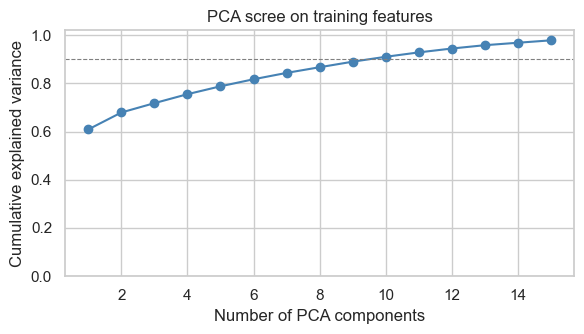

In [13]:
n_components = 15
pca_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("pca",   PCA(n_components=n_components, random_state=SEED)),
])
pca_pipe.fit(X_train)
X_train_pca = pca_pipe.transform(X_train)
X_test_pca  = pca_pipe.transform(X_test)

explained = pca_pipe.named_steps["pca"].explained_variance_ratio_
print(f"PCA with {n_components} components explains "
      f"{explained.sum() * 100:.1f}% of the variance in the training features")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, n_components + 1), np.cumsum(explained), marker="o", color="steelblue")
ax.axhline(0.90, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA scree on training features")
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_pca_scree.png", dpi=120)
plt.show()

In [14]:
lr_baseline = LogisticRegression(
    max_iter=2000, solver="lbfgs", random_state=SEED
)
lr_baseline.fit(X_train_pca, y_train)
lr_baseline_pred = lr_baseline.predict(X_test_pca)
lr_baseline_proba = lr_baseline.predict_proba(X_test_pca)
lr_baseline_metrics = {
    "accuracy": accuracy_score(y_test, lr_baseline_pred),
    "f1_macro": f1_score(y_test, lr_baseline_pred, average="macro"),
    "f1_weighted": f1_score(y_test, lr_baseline_pred, average="weighted"),
    "roc_auc_ovr": roc_auc_score(
        pd.get_dummies(y_test)[lr_baseline.classes_].values,
        lr_baseline_proba,
        multi_class="ovr", average="macro",
    ),
}
print("Baseline Multinomial Logistic on PCA:")
for k, v in lr_baseline_metrics.items():
    print(f"  {k:>15}: {v:.4f}")

Baseline Multinomial Logistic on PCA:
         accuracy: 0.7930
         f1_macro: 0.7969
      f1_weighted: 0.7951
      roc_auc_ovr: 0.9400


### Baseline Logistic Regression interpretation

The linear model on 15 PCA components reaches 0.793 accuracy and 0.940 ROC-AUC, about
five points below the Random Forest baseline. The gap is larger in F1-macro (0.797 vs
0.850) than in ROC-AUC (0.940 vs 0.962), so the logistic model ranks probabilities
nearly as well as the Random Forest but places the decision threshold in worse places.
The Walmsley classes are separable by linear combinations of the principal components
up to a point; the nonlinear boundaries the Random Forest picks up supply the last few
percentage points.

In [15]:
lr_grid = {"C": [0.1, 1.0, 10.0]}
lr_search = GridSearchCV(
    LogisticRegression(max_iter=3000, solver="lbfgs", random_state=SEED),
    lr_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=0,
)
lr_search.fit(X_train_pca, y_train)

print("Best LR C:", lr_search.best_params_["C"])
print(f"CV f1_macro: {lr_search.best_score_:.4f}")

lr_tuned = lr_search.best_estimator_
lr_tuned_pred = lr_tuned.predict(X_test_pca)
lr_tuned_proba = lr_tuned.predict_proba(X_test_pca)
lr_tuned_metrics = {
    "accuracy": accuracy_score(y_test, lr_tuned_pred),
    "f1_macro": f1_score(y_test, lr_tuned_pred, average="macro"),
    "f1_weighted": f1_score(y_test, lr_tuned_pred, average="weighted"),
    "roc_auc_ovr": roc_auc_score(
        pd.get_dummies(y_test)[lr_tuned.classes_].values,
        lr_tuned_proba,
        multi_class="ovr", average="macro",
    ),
}
print("\nTuned Multinomial Logistic on PCA (test set):")
for k, v in lr_tuned_metrics.items():
    print(f"  {k:>15}: {v:.4f}")

Best LR C: 0.1
CV f1_macro: 0.8342

Tuned Multinomial Logistic on PCA (test set):
         accuracy: 0.7954
         f1_macro: 0.7989
      f1_weighted: 0.7972
      roc_auc_ovr: 0.9403


### Tuned Logistic Regression interpretation

The grid picked `C = 0.1`, the strongest regularisation tried. Accuracy moves from 0.793
to 0.795 and F1-macro from 0.797 to 0.799. The improvement is marginal; PCA has already
done most of the dimensionality work, so pushing the coefficients further toward zero
buys almost nothing. As with the Random Forest, baseline and tuned linear models land
in the same place, and the agreement between the two makes the result more credible,
not less.

## 9. Model Comparison

In [16]:
comparison = pd.DataFrame([
    {"Model": "RF Baseline",      **rf_baseline_metrics},
    {"Model": "RF Tuned",         **rf_tuned_metrics},
    {"Model": "LR Baseline (PCA)", **lr_baseline_metrics},
    {"Model": "LR Tuned (PCA)",    **lr_tuned_metrics},
])
comparison = comparison.round(4)
comparison

,Model,accuracy,f1_macro,f1_weighted,roc_auc_ovr
0,RF Baseline,0.8466,0.8498,0.8469,0.9620
1,RF Tuned,0.8510,0.8540,0.8512,0.9628
2,LR Baseline (PCA),0.7930,0.7969,0.7951,0.9400
3,LR Tuned (PCA),0.7954,0.7989,0.7972,0.9403


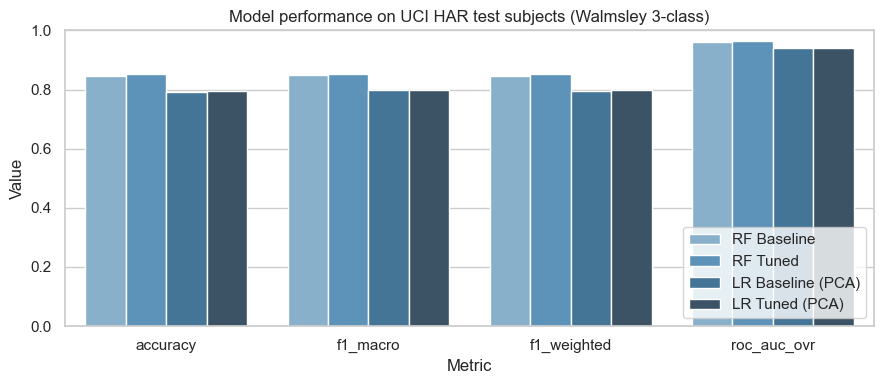

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
metric_cols = ["accuracy", "f1_macro", "f1_weighted", "roc_auc_ovr"]
plot_df = comparison.melt(
    id_vars="Model", value_vars=metric_cols,
    var_name="Metric", value_name="Value"
)
sns.barplot(
    data=plot_df, x="Metric", y="Value", hue="Model",
    palette="Blues_d", ax=ax,
)
ax.set_ylim(0, 1.0)
ax.set_title("Model performance on UCI HAR test subjects (Walmsley 3-class)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_model_comparison.png", dpi=120)
plt.show()

### Comparison interpretation

Random Forest wins every metric, by roughly five to six points on accuracy and F1 and
about two points on ROC-AUC. The gap is consistent across metrics rather than
concentrated on one, so it is a real performance difference and not a thresholding
artefact. The trade-off between the two model families is the usual one: the logistic
model is cheap, interpretable, and caps out at the PCA-projected linear boundary; the
Random Forest handles the nonlinear boundary and pays a small price in interpretability
and compute. The ranking of tree above linear on this kind of tabular multi-class
problem with nonlinear boundaries is the standard textbook outcome, and the numbers
here are consistent with that pattern.

## 10. Confusion Matrices and Per-Class Details

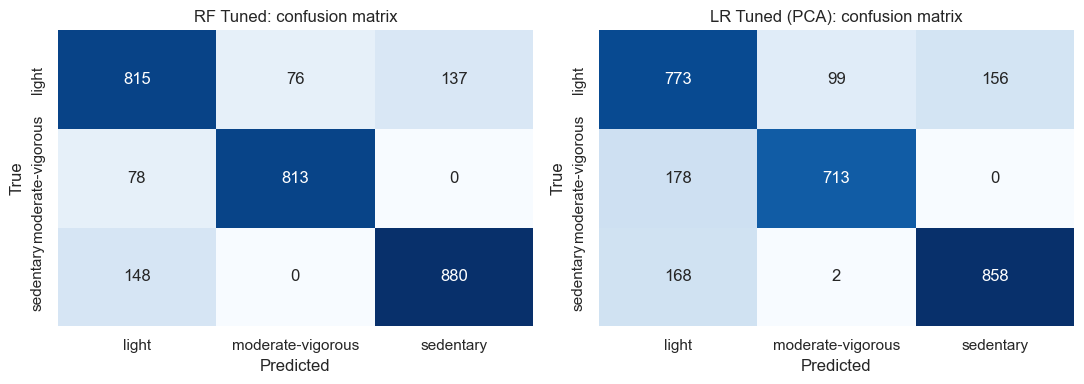

Per-class report for Tuned RF:
                   precision    recall  f1-score   support

            light     0.7829    0.7928    0.7878      1028
moderate-vigorous     0.9145    0.9125    0.9135       891
        sedentary     0.8653    0.8560    0.8606      1028

         accuracy                         0.8510      2947
        macro avg     0.8542    0.8538    0.8540      2947
     weighted avg     0.8514    0.8510    0.8512      2947

Per-class report for Tuned LR (PCA):
                   precision    recall  f1-score   support

            light     0.6908    0.7519    0.7201      1028
moderate-vigorous     0.8759    0.8002    0.8364       891
        sedentary     0.8462    0.8346    0.8404      1028

         accuracy                         0.7954      2947
        macro avg     0.8043    0.7956    0.7989      2947
     weighted avg     0.8010    0.7954    0.7972      2947



In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, pred) in zip(axes, [("RF Tuned", rf_tuned_pred),
                                   ("LR Tuned (PCA)", lr_tuned_pred)]):
    cm = confusion_matrix(y_test, pred, labels=class_labels)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels, cbar=False, ax=ax)
    ax.set_title(f"{name}: confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_confusion_matrices.png", dpi=120)
plt.show()

print("Per-class report for Tuned RF:")
print(classification_report(y_test, rf_tuned_pred, digits=4))
print("Per-class report for Tuned LR (PCA):")
print(classification_report(y_test, lr_tuned_pred, digits=4))

### Confusion matrix interpretation

Both models agree on the easy part. Moderate-vigorous and sedentary never confuse in
either matrix: zero moderate-vigorous windows are predicted as sedentary and zero
sedentary windows are predicted as moderate-vigorous. Vigorous motion and no motion
are cleanly separable. The hard part is the light class, which in the Walmsley mapping
bundles UCI HAR's Standing (static) and Walking (dynamic) into one label.

The Random Forest makes 213 light errors, split between sedentary (137) and
moderate-vigorous (76). That split tracks the internal composition of the class: the
static half of light gets misread as sedentary, the dynamic half as moderate-vigorous.
The logistic model makes 255 light errors on a similar pattern, with most of the extra
errors coming from the moderate-vigorous direction (178 MV predicted as light versus
the Random Forest's 78). The linear boundary is weakest on the walking/stairs
distinction.

Per-class F1 for the tuned Random Forest: moderate-vigorous 0.913, sedentary 0.861,
light 0.788. Light is the ceiling for the aggregate metric on this dataset; the route
to higher accuracy goes through the light class, either by improving it directly or
by revisiting the harmonisation.

## 11. Feature Importance and PCA Loadings

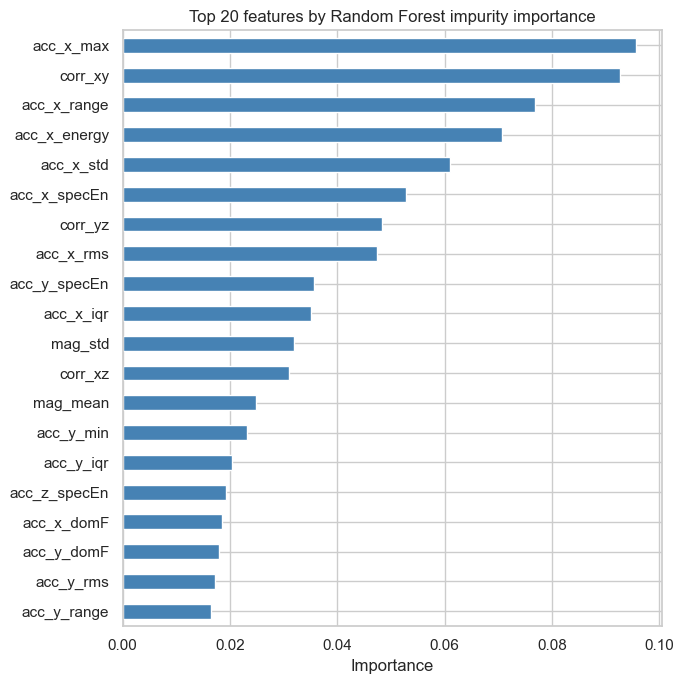

In [19]:
fi = pd.Series(rf_tuned.feature_importances_, index=feature_cols)
fi_sorted = fi.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 7))
fi_sorted.head(20).sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Top 20 features by Random Forest impurity importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_rf_importance.png", dpi=120)
plt.show()

In [20]:
pca_obj = pca_pipe.named_steps["pca"]
loadings = pd.DataFrame(
    pca_obj.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(n_components)],
)
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10).index
loadings_top = loadings.loc[top_pc1, ["PC1", "PC2", "PC3"]]
print("Top contributors to PC1, PC2, PC3:")
loadings_top.round(3)

Top contributors to PC1, PC2, PC3:


,PC1,PC2,PC3
mag_mean,0.212,-0.005,0.027
mag_max,0.210,0.016,0.016
acc_x_range,0.208,0.047,0.061
acc_y_std,0.208,-0.014,0.010
mag_std,0.208,0.005,0.022
acc_y_range,0.207,0.017,0.014
acc_x_rms,0.207,0.047,0.078
acc_x_std,0.207,0.052,0.082
acc_y_rms,0.206,-0.032,0.002
acc_x_min,-0.206,-0.034,-0.021


### Feature importance interpretation

Four of the top five Random Forest features come from the accelerometer x-axis
(`acc_x_max`, `acc_x_range`, `acc_x_energy`, `acc_x_std`), with the cross-axis
correlation `corr_xy` in second place. UCI HAR participants wore the phone in a belt
pouch with the device's x-axis aligned with the medio-lateral direction of the body,
so the x-axis is the one that captures pelvic sway during walking and the step-up
motion during stairs. Cross-axis correlations (`corr_xy` at 0.093, `corr_yz` at 0.048)
separate coordinated locomotion from static or unstructured postures. Frequency-domain
features show up in the middle of the ranking rather than at the top: spectral entropy
on x and y makes the top ten, dominant frequency does not. For this dataset and this
feature bank, amplitude statistics carry more intensity-class signal than periodicity.

The x-axis dominance is a reminder that this result is specific to UCI HAR's waist
placement. The same features would rank differently on a wrist-worn or hip-worn
device, because the mapping from body movement to each device axis changes with
placement. The baseline here is a reference for UCI HAR specifically and should be
read that way, not as a general statement about activity classification.

## 12. Save Artifacts for Reproducibility

Every test-set prediction, the fitted models, the engineered feature matrix, and a
metrics JSON are written under `artifacts/` so the run can be verified or reused
without re-executing the notebook.

In [21]:
import joblib  # noqa: E402

# Metrics
metrics_payload = {
    "dataset":          "uci_har",
    "label_scheme":     "walmsley",
    "n_classes":        len(class_labels),
    "classes":          list(class_labels),
    "feature_count":    len(feature_cols),
    "pca_components":   n_components,
    "pca_explained_cum": float(np.cumsum(explained)[-1]),
    "models": {
        "rf_baseline":    rf_baseline_metrics,
        "rf_tuned":       {**rf_tuned_metrics, "best_params": rf_search.best_params_},
        "lr_baseline":    lr_baseline_metrics,
        "lr_tuned":       {**lr_tuned_metrics, "best_params": lr_search.best_params_},
    },
    "seed":             SEED,
    "note":             "Generated by CHEP 898 Assignment 9; reproducible via Assignment9.ipynb",
}
with open(ARTIFACT_DIR / "metrics.json", "w") as fh:
    json.dump(metrics_payload, fh, indent=2)

# Predictions CSV
pred_df = pd.DataFrame({
    "subject_id":     test["subject_id"].values,
    "y_true":         y_test,
    "rf_tuned_pred":  rf_tuned_pred,
    "lr_tuned_pred":  lr_tuned_pred,
})
for i, cls in enumerate(rf_tuned.classes_):
    pred_df[f"rf_proba_{cls}"] = rf_tuned_proba[:, i]
for i, cls in enumerate(lr_tuned.classes_):
    pred_df[f"lr_proba_{cls}"] = lr_tuned_proba[:, i]
pred_df.to_csv(ARTIFACT_DIR / "predictions.csv", index=False)

# Engineered feature matrix, saved for inspection and reuse
features[["subject_id", "split", "y"] + feature_cols].to_csv(
    ARTIFACT_DIR / "uci_har_walmsley_features.csv", index=False
)

# Trained models
joblib.dump(rf_tuned, ARTIFACT_DIR / "rf_tuned.joblib")
joblib.dump(lr_search.best_estimator_, ARTIFACT_DIR / "lr_tuned.joblib")
joblib.dump(pca_pipe, ARTIFACT_DIR / "pca_pipeline.joblib")

print("Artifacts saved to ./artifacts/:")
for p in sorted(ARTIFACT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<40s} ({size_kb:,.1f} KB)")

Artifacts saved to ./artifacts/:
  fig_class_balance.png                    (32.8 KB)
  fig_confusion_matrices.png               (38.8 KB)
  fig_example_windows.png                  (140.1 KB)
  fig_model_comparison.png                 (34.5 KB)
  fig_pca_scree.png                        (28.5 KB)
  fig_rf_importance.png                    (51.4 KB)
  fig_subject_windows.png                  (21.1 KB)
  lr_tuned.joblib                          (1.4 KB)
  metrics.json                             (1.2 KB)
  pca_pipeline.joblib                      (7.1 KB)
  predictions.csv                          (395.8 KB)
  rf_tuned.joblib                          (56,751.4 KB)
  uci_har_walmsley_features.csv            (7,126.0 KB)


## 13. Discussion

The tuned Random Forest reaches 0.851 accuracy, 0.854 macro-F1, and 0.963 ROC-AUC on
nine held-out subjects under the Walmsley three-class scheme. The tuned multinomial
logistic regression on fifteen PCA components reaches 0.795 accuracy, 0.799 macro-F1,
and 0.940 ROC-AUC. Random Forest wins every metric. The gap is widest on macro-F1
(0.854 vs 0.799), which means the logistic model is ranking probabilities nearly as
well as the Random Forest but placing its decision threshold in worse places. Tuning
adds almost nothing in either model: half a percentage point of accuracy for the
Random Forest, two tenths for the logistic. The defaults were already near the
performance available to each model family.

The confusion matrices show the easy side of the problem is already solved. Vigorous
motion and no motion are cleanly separable; moderate-vigorous and sedentary never
confuse in either model. The whole difficulty sits in the light class, which in the
Walmsley mapping bundles Standing (static) and Walking (dynamic) together. The Random
Forest makes 213 light errors that split into 137 toward sedentary and 76 toward
moderate-vigorous; that split tracks the internal composition of the class. The
logistic model makes 255 light errors with a heavier moderate-vigorous drift (178
versus 78). The ceiling for the overall metric on this dataset is set by how well a
classifier resolves that internal mixture, not by the rest of the problem.

Feature importance is x-axis dominant and correlation-assisted. The top five
contributors are `acc_x_max`, `corr_xy`, `acc_x_range`, `acc_x_energy`, and
`acc_x_std`. UCI HAR's waist placement aligns the device x-axis with the medio-lateral
direction of the body, which is the axis that picks up the pelvic-sway rhythm of
walking and the step-up displacement of stairs. Amplitude statistics outrank
frequency-domain features for this label set, and the result is tied to the UCI HAR
placement rather than being a general feature about intensity classification.

### Limitations

The feature bank is deliberately conservative. Autocorrelation, wavelet coefficients,
and jerk-domain features are known to help on HAR tasks but are not included here;
this is a classification baseline, not a feature-engineering study. PCA is fitted on
the engineered features rather than on the raw signals, so it captures covariance
among summary statistics rather than among time series directly. The training set is
used both for five-fold cross-validation and for the final fit; the held-out test
subjects are the only unbiased performance estimate, and there is no separate
calibration fold. The Walmsley mapping of UCI HAR used here is defensible but not
unique; reclassifying Standing (currently "light") would change the shape of the
error distribution on the light class.